# Übung 5 – Umweltmessdaten: Lärm und ultrafeine Partikel am Breslauer Platz (Darmstadt)

Am **Mittwoch, 17.06.2026, ca. 09:00–09:25 Uhr** haben wir eine kurze **Feldmessung** an der
fünfarmigen Kreuzung **Breslauer Platz / Heinrichstraße** in Darmstadt-Ost durchgeführt (direkt am
Botanischen Garten / TU-Campus Lichtwiese). Gemessen wurde an **zwei Punkten**:

| Punkt | Lage | Koordinaten | Gerät |
|---|---|---|---|
| **S – Straße** | unmittelbar am Fahrbahnrand der Kreuzung | 49°52'02.6"N, 8°40'45.6"E | Partector 2 **Pro** (SN 8453) |
| **G – Gehweg** | Fuß-/Radweg *Schnampelweg*, ≈ 45 m abgesetzt | 49°52'01.8"N, 8°40'47.4"E | Partector 2 (SN 8066) |

Dazu lief **ein** Schallpegelmessgerät (**Trotec SL400**, dB(A), 1 Hz) durchgehend mit – zuerst am
Gehweg-Punkt, etwa ab der Hälfte der Messzeit am Straßen-Punkt. Zwei Drohnenfotos (DJI) dokumentieren
den Messort aus der Luft.

**Protokollierte Ereignisse:** Start ca. 09:00 Uhr am Gehweg; früh in der Messung passierte eine
**Kita-Gruppe** den Aufbau; zwischendurch **Drohnenflug** (Fotos 09:08 und 09:11 Uhr laut EXIF);
später **Wechsel an die Straße**; Gesamtdauer ≈ 23 Minuten.

Der Versuch war kurz (17–26 min je Gerät), die Standardmessdauer
von 15 min pro Standort wurde nicht eingehalten, der Schallpegelmesser wurde mitten in der Messung
umgesetzt, und Einzelereignisse (Kita-Gruppe, Drohne) prägen Teile der Zeitreihe. Für belastbare
Hypothesentests fehlen damit die Voraussetzungen – wir **beschreiben** die Daten stattdessen
sorgfältig und machen die Unsicherheiten (v. a. die Geräteuhren) explizit.

**Aufbau:** Setup → Geräte & Datenformate → Zeitbasis → Messorte → Schallpegel → Partikel →
gemeinsame Zeitachse → Exkurs naneos-Bibliothek → Fazit.

## 1. Setup und Dateninventar

In [1]:
from pathlib import Path
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

# ── Farbsystem (wie in Übung 4, CVD-geprüft) ─────────────────────────────────
SERIES = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
          "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
SURFACE = "#fcfcfb"
INK, INK2 = "#0b0b0b", "#52514e"

# Feste Farb-Zuordnung nach Entität (nie umsortieren):
COL_S = SERIES[0]   # Punkt S – Straße        (blau)
COL_G = SERIES[1]   # Punkt G – Gehweg        (grün)
COL_EV = SERIES[2]  # Ereignisse / Highlights (orange)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2,
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 10,
    "grid.color": "#d8d7d2", "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "lines.linewidth": 2.0, "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=SERIES),
})

BASE_DIR = Path.cwd()
print(f"Arbeitsverzeichnis: {BASE_DIR}\n")
for p in sorted(BASE_DIR.iterdir()):
    if p.is_file():
        print(f"{p.name:28s} {p.stat().st_size/1024:8.1f} kB")

Arbeitsverzeichnis: c:\Users\kevin\OneDrive - stud.tu-darmstadt.de\Uni_Master\Master_BauIng_4. Semester\Small and Big Data in der Verkehrstechnik\Übung 5 - Umweltmessdaten

2026-6-17 9-49.xls               49.7 kB
8066_085903.txt                 157.4 kB
8453_080333.txt                 120.5 kB
DJI_0524.JPG                   4094.0 kB
DJI_0526.JPG                   4109.8 kB
Links.txt                         0.2 kB
UE5_Umweltmessdaten.ipynb      2951.4 kB


## 2. Messgeräte und Datenformate

In [2]:
def load_partector(path):
    """Partector-2-Logdatei -> (Metadaten-Dict, DataFrame)."""
    lines = Path(path).read_text(encoding="latin-1").splitlines()
    hdr = next(i for i, l in enumerate(lines) if l.startswith("time\t"))
    meta = {"Datei": Path(path).name, "Seriennummer": lines[0].split("SN")[-1].strip()}
    for l in lines[:hdr]:
        if l.startswith("Firmware:"):
            meta["Firmware"] = l.split(":")[1].strip()
        elif l.startswith("Calibration:"):
            meta["kalibriert am"] = l.split("calibrated on")[-1].strip()
        elif l.startswith("Start:"):
            meta["Start (Geräteuhr)"] = l.split(": ", 1)[1].strip()
    df = pd.read_csv(io.StringIO("\n".join(lines[hdr:])), sep="\t")
    meta["Zeilen"], meta["Spalten"] = len(df), df.shape[1]
    return meta, df

def load_sl400(path):
    """Trotec-SL400-Export (Pseudo-.xls) -> (Metadaten-Dict, DataFrame)."""
    lines = Path(path).read_text(encoding="latin-1").splitlines()
    meta = {"Datei": Path(path).name}
    for l in lines[:5]:
        parts = l.split("\t")
        meta[parts[0]] = parts[1].strip()
    df = pd.read_csv(io.StringIO("\n".join(lines[5:])), sep="\t").dropna(axis=1, how="all")
    df["clock"] = pd.to_datetime(df["DateTime"], format="%d-%m-%Y,%H:%M:%S")
    return meta, df

meta_S, part_S = load_partector(BASE_DIR / "8453_080333.txt")   # Punkt S – Straße
meta_G, part_G = load_partector(BASE_DIR / "8066_085903.txt")   # Punkt G – Gehweg
meta_db, db    = load_sl400(BASE_DIR / "2026-6-17 9-49.xls")

display(pd.DataFrame([meta_S, meta_G], index=["Punkt S (Straße)", "Punkt G (Gehweg)"]))
print("SL400:", {k: v for k, v in meta_db.items() if k != "Datei"})

,Datei,Seriennummer,Firmware,kalibriert am,Start (Geräteuhr),Zeilen,Spalten
Punkt S (Straße),8453_080333.txt,8453,rev 298,10.11.2023,17.6.2026 08:03:49,1034,23
Punkt G (Gehweg),8066_085903.txt,8066,rev 113,30.4.2019,17.6.2026 08:59:19,1558,20


SL400: {'StartTime': '17-06-2026,15:32:00', 'Max': '77.10 @ 17-06-2026,15:55:09  dBA', 'Min': '43.80 @ 17-06-2026,15:43:46  dBA', 'Average': '56.23', 'SampleRate': '1.00'}


### Bedeutung der Partector-Spalten

| Spalte | Einheit | Bedeutung |
|---|---|---|
| `time` | s | Sekunden seit Gerätestart (1 Hz) |
| `number` | 1/cm³ | Partikel-**Anzahl**konzentration |
| `diam` | nm | mittlerer Partikeldurchmesser |
| `LDSA` | µm²/cm³ | **lungendeponierte Oberfläche** – die Kerngröße des Geräts |
| `surface` | µm²/cm³ | gesamte Partikeloberfläche |
| `mass` | µg/m³ | geschätzte Partikelmasse |
| `T`, `RH`, `P` | °C, %, hPa | Temperatur, rel. Feuchte, Luftdruck (im Gerät) |
| `flow`, `bat`, `error` | l/min, V, – | Pumpenfluss, Akku, Fehlerflags (0 = ok) |
| `A1/A2`, `idiff`, `HV`, `EM1/EM2`, `DV`, … | – | interne Gerätediagnose (Elektrometer, Hochspannung) |

Das Pro-Gerät (SN 8453, Firmware 298) loggt drei Diagnosespalten mehr (`PWMpump`, `2f1`, `2f2`) als
das ältere SN 8066 (Firmware 113) – zwei Gerätegenerationen, gleiche Kernspalten. Auffällig:
**SN 8066 wurde zuletzt am 30.04.2019 kalibriert**, SN 8453 am 10.11.2023. Absolute Niveauvergleiche
zwischen beiden Geräten sind deshalb mit einer Prise Salz zu genießen – die *Muster* (Spitzen,
Streuung, Verlauf) sind davon unberührt.

### Das Uhren-Problem: drei Geräte, drei Zeitbasen

| Gerät | Uhr sagt | real (rekonstruiert) | Begründung |
|---|---|---|---|
| SL400 | Start 17.06.2026 **15:32:00** | **≈ 09:00:00** | Protokoll: Start „um 9 Uhr"; Uhr nie gestellt → Offset −6:32 h |
| Partector G (8066) | Start **08:59:19** | **≈ 08:59** (übernommen) | passt auf die Minute zum protokollierten Beginn |
| Partector S (8453) | Start **08:03:49** | **≈ 09:03:49** (+1 h) | plausibel Winterzeit-Offset (CET statt CEST); Header zeigt `0 RTCcal` |


In [3]:
# ── Zeitbasen rekonstruieren + Datenqualität prüfen ──────────────────────────
DB_OFFSET = pd.Timedelta(hours=-6, minutes=-32)            # 15:32:00 -> 09:00:00
db["t_real"] = db["clock"] + DB_OFFSET

start_S = pd.Timestamp("2026-06-17 08:03:49") + pd.Timedelta(hours=1)   # Winterzeit-Hypothese
start_G = pd.Timestamp("2026-06-17 08:59:19")
part_S["t_real"] = start_S + pd.to_timedelta(part_S["time"], unit="s")
part_G["t_real"] = start_G + pd.to_timedelta(part_G["time"], unit="s")

qc = []
for name, df, tcol in [("Partector S (8453)", part_S, "time"),
                       ("Partector G (8066)", part_G, "time"),
                       ("SL400 dB(A)", db, None)]:
    steps = (df[tcol].diff().dropna() if tcol
             else db["clock"].diff().dropna().dt.total_seconds())
    qc.append({
        "Gerät": name,
        "Zeilen": len(df),
        "Dauer [min]": round(len(df) / 60, 1),
        "Lücken (Δt ≠ 1 s)": int((steps != 1).sum()),
        "Fehlerflags": int(df["error"].ne(0).sum()) if "error" in df else "–",
        "real von": df["t_real"].iloc[0].strftime("%H:%M:%S"),
        "real bis": df["t_real"].iloc[-1].strftime("%H:%M:%S"),
    })
display(pd.DataFrame(qc).set_index("Gerät"))

warm = int((part_S["RH"] == 0).sum())
print(f"Aufwärm-Artefakt Partector S: {warm} Zeile(n) mit RH = 0 direkt nach dem Einschalten "
      "(Sensor initialisiert) – wird belassen, fällt statistisch nicht ins Gewicht.")

,Zeilen,Dauer [min],Lücken (Δt ≠ 1 s),Fehlerflags,real von,real bis
Gerät,,,,,,
Partector S (8453),1034,17.2,0,0,09:03:50,09:21:03
Partector G (8066),1558,26.0,0,0,08:59:20,09:25:17
SL400 dB(A),1400,23.3,0,–,09:00:00,09:23:19


Aufwärm-Artefakt Partector S: 1 Zeile(n) mit RH = 0 direkt nach dem Einschalten (Sensor initialisiert) – wird belassen, fällt statistisch nicht ins Gewicht.


## 3. Die Messorte

Der Straßen-Punkt liegt direkt an der Kreuzung **Breslauer Platz**, wo die **Heinrichstraße**
(Hauptsammelstraße mit Busspuren und Tempo-30-Markierung) auf Roßdörfer Straße, Schnittspahnstraße
und Eugen-Kogon-Straße trifft – die Straßenbahn- und Bushaltestelle „Botanischer Garten" liegt
unmittelbar daneben. Der Gehweg-Punkt liegt ≈ 45 m südöstlich auf dem **Schnampelweg**, einem
begrünten Fuß-/Radweg Richtung Lichtwiese – abgeschirmt durch Bäume, ohne direkten Kfz-Verkehr.
Die Drohnenfotos tragen GPS-Koordinaten und Zeitstempel im EXIF-Header – sie dienen uns gleich
doppelt: als Lagedokumentation und als **Zeitanker** (Abschnitt 2).

In [4]:
from math import radians, sin, cos, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, (lat1, lon1, lat2, lon2))
    return 2 * 6371000 * asin(sqrt(sin((lat2 - lat1) / 2) ** 2 +
                                   cos(lat1) * cos(lat2) * sin((lon2 - lon1) / 2) ** 2))

SPOT_S = (49 + 52/60 + 2.6/3600, 8 + 40/60 + 45.6/3600)   # Straße
SPOT_G = (49 + 52/60 + 1.8/3600, 8 + 40/60 + 47.4/3600)   # Gehweg
PHOTOS = [("DJI_0524.JPG", 49.867393, 8.679477, "09:08:12"),
          ("DJI_0526.JPG", 49.867453, 8.679101, "09:11:02")]

dist = haversine(*SPOT_S, *SPOT_G)
print(f"Abstand der Messpunkte: {dist:.1f} m")

import folium
mid = [(SPOT_S[0] + SPOT_G[0]) / 2, (SPOT_S[1] + SPOT_G[1]) / 2]
m = folium.Map(location=mid, zoom_start=18, tiles="OpenStreetMap", control_scale=True)
folium.CircleMarker(SPOT_S, radius=9, color=COL_S, fill=True, fill_opacity=.85,
                    tooltip=folium.Tooltip("Punkt S – Straße (Partector 2 Pro, SN 8453)",
                                           permanent=True, direction="left")).add_to(m)
folium.CircleMarker(SPOT_G, radius=9, color=COL_G, fill=True, fill_opacity=.85,
                    tooltip=folium.Tooltip("Punkt G – Gehweg (Partector 2, SN 8066)",
                                           permanent=True, direction="right")).add_to(m)
folium.PolyLine([SPOT_S, SPOT_G], color=INK2, weight=2, dash_array="6",
                tooltip=f"{dist:.0f} m").add_to(m)
for name, lat, lon, t in PHOTOS:
    folium.Marker([lat, lon], icon=folium.Icon(icon="camera", prefix="fa", color="orange"),
                  tooltip=folium.Tooltip(f"{name} – {t} Uhr (EXIF)",
                                         permanent=True, direction="top")).add_to(m)
m

Abstand der Messpunkte: 43.5 m


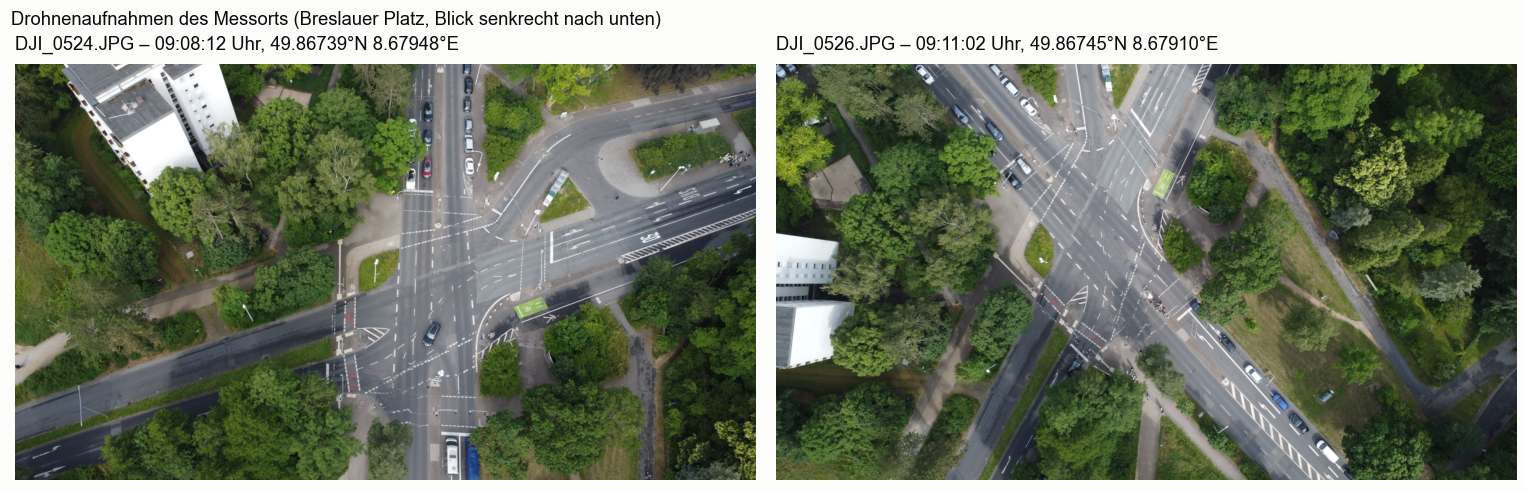

In [5]:
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, (name, lat, lon, t) in zip(axes, PHOTOS):
    img = Image.open(BASE_DIR / name)
    img.thumbnail((1200, 1200))
    ax.imshow(img)
    ax.set_title(f"{name} – {t} Uhr, {lat:.5f}°N {lon:.5f}°E")
    ax.axis("off")
fig.suptitle("Drohnenaufnahmen des Messorts (Breslauer Platz, Blick senkrecht nach unten)",
             x=0.01, ha="left", fontsize=12)
plt.tight_layout()

Die Luftbilder zeigen die Situation gut: eine große, **lichtsignalgeregelte fünfarmige Kreuzung** mit
Busspur, Radverkehrsanlagen und wartenden Fahrzeugpulks – und direkt daneben ausgedehntes Grün. Auf
dem zweiten Foto ist am unteren Bildrand sogar eine Personengruppe am Kreuzungsrand zu erkennen –
unser Messtrupp. Die beiden Messpunkte trennen nur ≈ 44 m Luftlinie, aber ein kompletter
Nutzungskontext: Fahrbahnrand vs. begrünter Weg.

## 4. Schallpegel (Trotec SL400)

Der SL400 liefert **A-bewertete Momentanpegel** im Sekundentakt. Weil Dezibel logarithmisch sind,
darf man sie nicht arithmetisch mitteln – der **energieäquivalente Dauerschallpegel**
$L_{eq} = 10 \cdot \lg\!\big(\tfrac{1}{n}\sum 10^{L_i/10}\big)$ ist das korrekte Mittel. Zusätzlich
beschreiben **Perzentilpegel** die Verteilung: $L_{90}$ (in 90 % der Zeit überschritten) ≈
Hintergrundpegel, $L_{10}$ ≈ Spitzenpegel des Verkehrs.

Die Zeitreihe zerfällt sichtbar in **drei Phasen**, die exakt zum Protokoll passen: (A) Aufbau am
Gehweg mit Ereignissen (Kita-Gruppe, Drohnenstart), (B) ruhige Gehweg-Phase, (C) an der Straße. Den
Wechsel B→C erkennen wir automatisch als ersten Zeitpunkt (nach Minute ~12), ab dem der gleitende
60-s-Leq dauerhaft über 56 dB(A) springt.

Wechsel an die Straße erkannt um 09:16:30 Uhr (Sekunde 990)


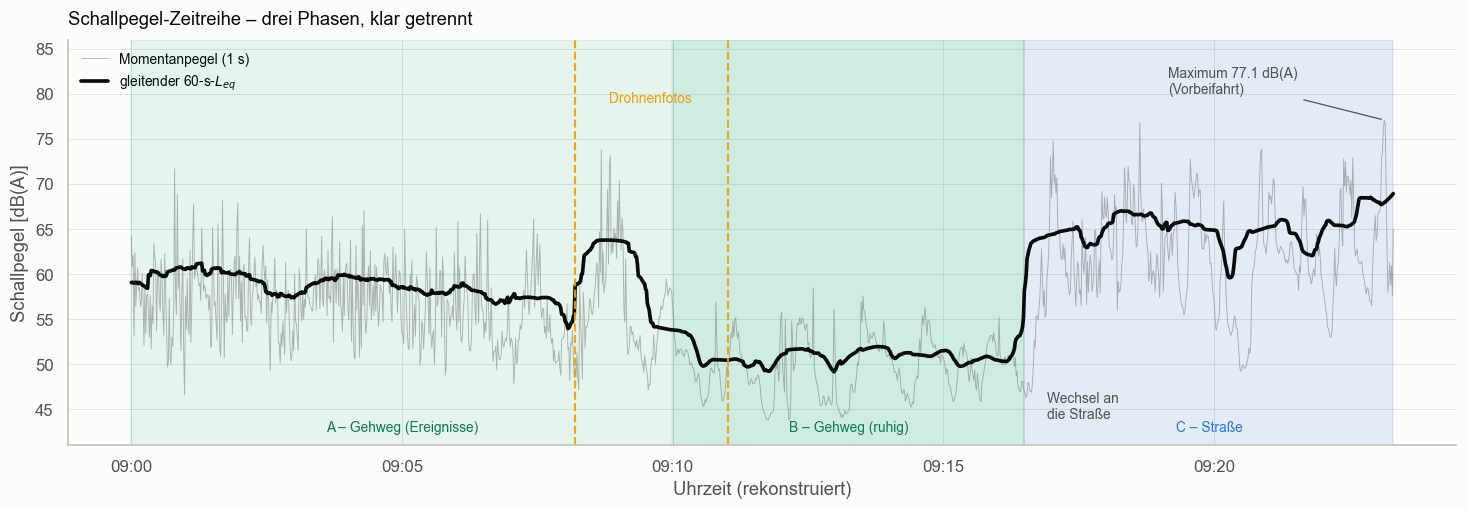

In [6]:
v = db["Value"].to_numpy()

def leq(x):
    return 10 * np.log10(np.mean(10 ** (np.asarray(x, dtype=float) / 10)))

db["leq60"] = 10 * np.log10(pd.Series(10 ** (v / 10))
                            .rolling(60, center=True, min_periods=30).mean()).to_numpy()

# Phasenwechsel B -> C automatisch bestimmen
t_s = np.arange(len(db))
i_switch = int(np.where((t_s > 700) & (db["leq60"].to_numpy() > 56))[0][0])
t_switch = db["t_real"].iloc[i_switch]
print(f"Wechsel an die Straße erkannt um {t_switch:%H:%M:%S} Uhr (Sekunde {i_switch})")

PH_A = slice(0, 600)            # Gehweg: Aufbau + Ereignisse (erste 10 min)
PH_B = slice(600, i_switch)     # Gehweg: ruhig
PH_C = slice(i_switch, len(db)) # Straße

fig, ax = plt.subplots(figsize=(13.5, 4.8))
ax.axvspan(db["t_real"].iloc[0], db["t_real"].iloc[599], color=COL_G, alpha=.10)
ax.axvspan(db["t_real"].iloc[600], t_switch, color=COL_G, alpha=.20)
ax.axvspan(t_switch, db["t_real"].iloc[-1], color=COL_S, alpha=.12)
ax.plot(db["t_real"], v, lw=.6, alpha=.4, color=INK2, label="Momentanpegel (1 s)")
ax.plot(db["t_real"], db["leq60"], lw=2.4, color=INK, label="gleitender 60-s-$L_{eq}$")

for _, lat, lon, t in [PHOTOS[0], PHOTOS[1]]:
    ax.axvline(pd.Timestamp(f"2026-06-17 {t}"), color=COL_EV, lw=1.4, ls="--", alpha=.9)
ax.text(pd.Timestamp("2026-06-17 09:09:35"), 79, "Drohnenfotos", color=COL_EV, ha="center", fontsize=9)

i_maxA = int(np.argmax(v[PH_A]))
i_max = int(np.argmax(v))
ax.annotate(f"Maximum {v[i_max]:.1f} dB(A)\n(Vorbeifahrt)",
            xy=(db["t_real"].iloc[i_max], v[i_max]),
            xytext=(db["t_real"].iloc[i_max] - pd.Timedelta(minutes=4), 80),
            fontsize=9, color=INK2, arrowprops=dict(arrowstyle="-", color=INK2, lw=.8))
ax.annotate("Wechsel an\ndie Straße", xy=(t_switch, 45), xytext=(t_switch + pd.Timedelta(seconds=25), 44),
            fontsize=9, color=INK2)

ax.text(db["t_real"].iloc[300], 42.5, "A – Gehweg (Ereignisse)", color="#0e7a52", fontsize=9, ha="center")
ax.text(db["t_real"].iloc[(600 + i_switch)//2], 42.5, "B – Gehweg (ruhig)", color="#0e7a52", fontsize=9, ha="center")
ax.text(db["t_real"].iloc[(i_switch + len(db))//2], 42.5, "C – Straße", color=COL_S, fontsize=9, ha="center")

ax.set_ylim(41, 86)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("Uhrzeit (rekonstruiert)"); ax.set_ylabel("Schallpegel [dB(A)]")
ax.set_title("Schallpegel-Zeitreihe – drei Phasen, klar getrennt")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

,Dauer [s],Leq,L10,L50,L90,Min,Max
Phase,,,,,,,
A – Gehweg (Aufbau/Ereignisse),600,59.5,62.3,56.4,51.2,46.6,73.8
B – Gehweg (ruhig),390,50.8,54.3,49.7,45.6,43.8,58.5
C – Straße,410,65.5,69.5,61.8,54.1,46.3,77.1
Gesamt,1400,61.6,64.8,55.9,48.0,43.8,77.1


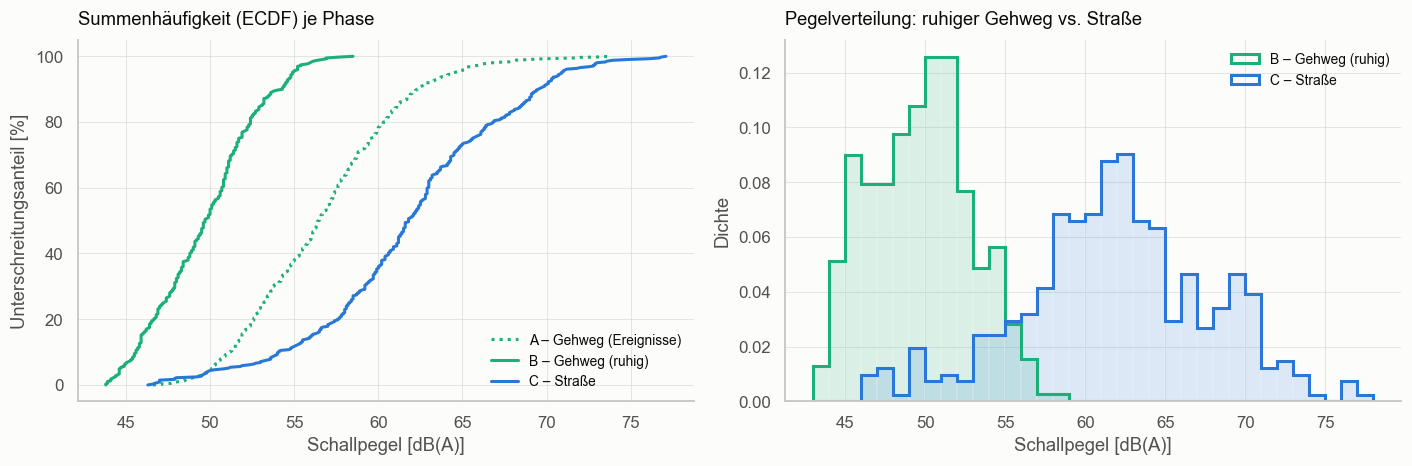

In [7]:
def lstats(x, label):
    x = np.asarray(x, dtype=float)
    return {"Phase": label, "Dauer [s]": len(x), "Leq": leq(x),
            "L10": np.percentile(x, 90), "L50": np.percentile(x, 50),
            "L90": np.percentile(x, 10), "Min": x.min(), "Max": x.max()}

stats = pd.DataFrame([
    lstats(v[PH_A], "A – Gehweg (Aufbau/Ereignisse)"),
    lstats(v[PH_B], "B – Gehweg (ruhig)"),
    lstats(v[PH_C], "C – Straße"),
    lstats(v,       "Gesamt"),
]).set_index("Phase").round(1)
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
phase_def = [("A – Gehweg (Ereignisse)", v[PH_A], COL_G, ":"),
             ("B – Gehweg (ruhig)",      v[PH_B], COL_G, "-"),
             ("C – Straße",              v[PH_C], COL_S, "-")]

ax = axes[0]
for label, x, c, ls in phase_def:
    xs = np.sort(x)
    ax.plot(xs, np.linspace(0, 100, len(xs)), color=c, ls=ls, label=label)
ax.set_xlabel("Schallpegel [dB(A)]"); ax.set_ylabel("Unterschreitungsanteil [%]")
ax.set_title("Summenhäufigkeit (ECDF) je Phase")
ax.legend(fontsize=9)

ax = axes[1]
bins = np.arange(43, 79, 1)
for label, x, c, ls in phase_def[1:]:
    ax.hist(x, bins=bins, density=True, histtype="step", lw=2, color=c, label=label)
    ax.hist(x, bins=bins, density=True, alpha=.15, color=c)
ax.set_xlabel("Schallpegel [dB(A)]"); ax.set_ylabel("Dichte")
ax.set_title("Pegelverteilung: ruhiger Gehweg vs. Straße")
ax.legend(fontsize=9)
plt.tight_layout()

## 5. Ultrafeine Partikel (Partector 2)

Anders als beim Schall haben wir hier **zwei Geräte parallel** – je eines pro Punkt. Wir betrachten
die Kerngrößen LDSA, Anzahl und Durchmesser zunächst je Gerät auf seiner eigenen relativen
Zeitachse (Minuten seit Gerätestart), damit keine Uhren-Annahme in die Beschreibung einfließt.

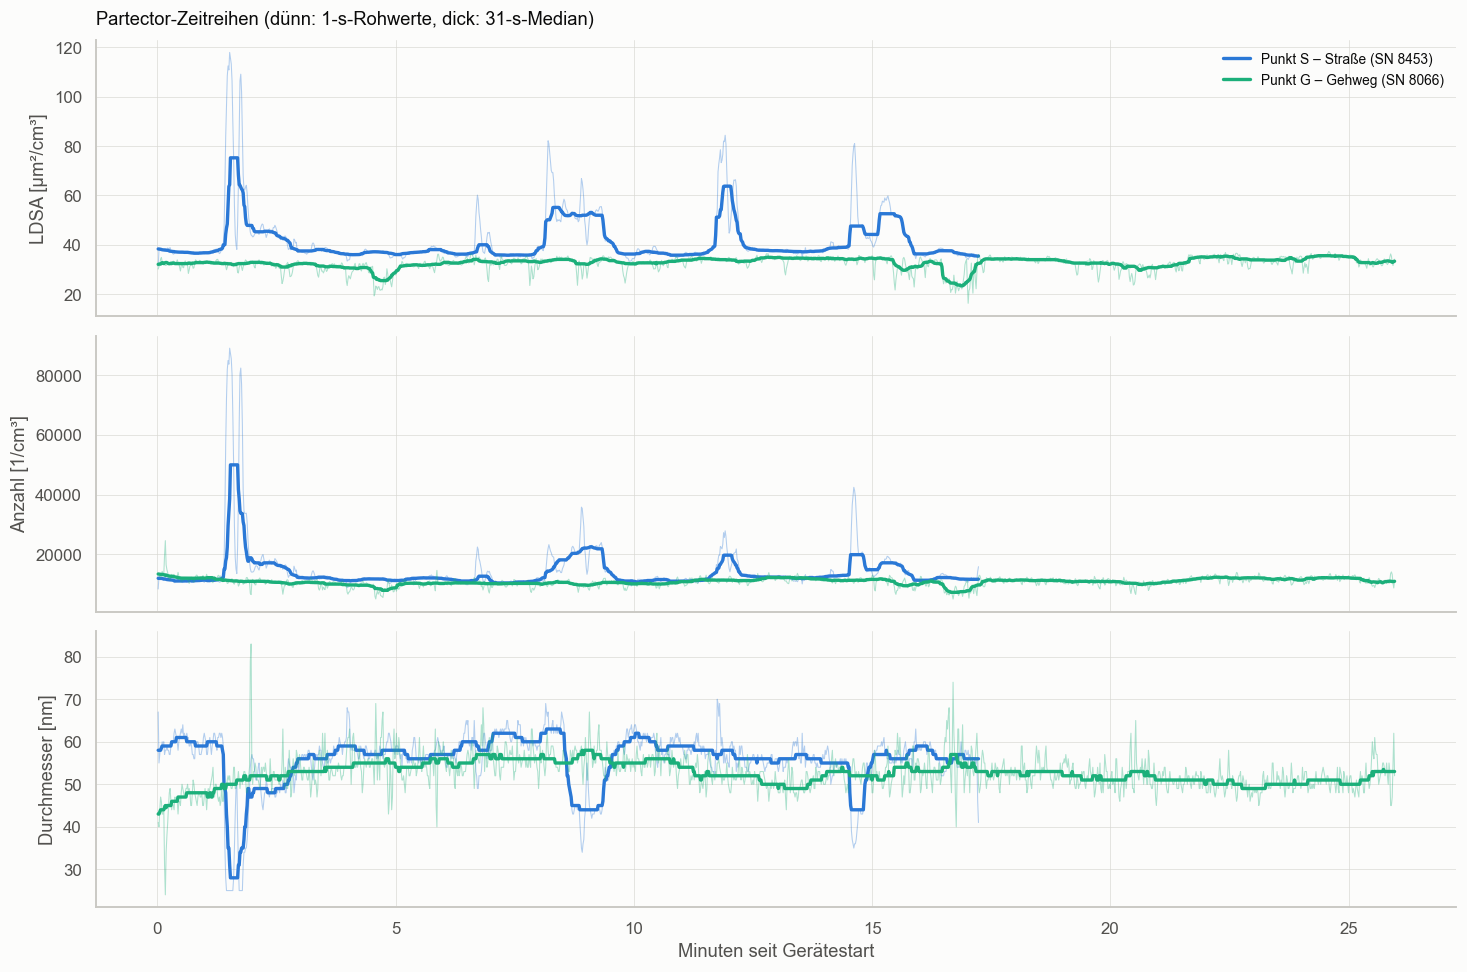

In [8]:
panels = [("LDSA", "LDSA [µm²/cm³]"), ("number", "Anzahl [1/cm³]"), ("diam", "Durchmesser [nm]")]
fig, axes = plt.subplots(3, 1, figsize=(13.5, 9), sharex=True)
for ax, (col, ylab) in zip(axes, panels):
    for df, c, label in [(part_S, COL_S, "Punkt S – Straße (SN 8453)"),
                         (part_G, COL_G, "Punkt G – Gehweg (SN 8066)")]:
        tmin = df["time"] / 60
        ax.plot(tmin, df[col], lw=.7, alpha=.35, color=c)
        ax.plot(tmin, df[col].rolling(31, center=True, min_periods=10).median(),
                lw=2.2, color=c, label=label)
    ax.set_ylabel(ylab)
axes[0].legend(fontsize=9, loc="upper right")
axes[0].set_title("Partector-Zeitreihen (dünn: 1-s-Rohwerte, dick: 31-s-Median)")
axes[-1].set_xlabel("Minuten seit Gerätestart")
plt.tight_layout()

Punkt S: 65 Sekunden (6.3 % der Messzeit) mit LDSA > 60 µm²/cm³ – verteilt auf mehrere Abgasfahnen.
Punkt G: 0 Sekunden über 60 µm²/cm³.


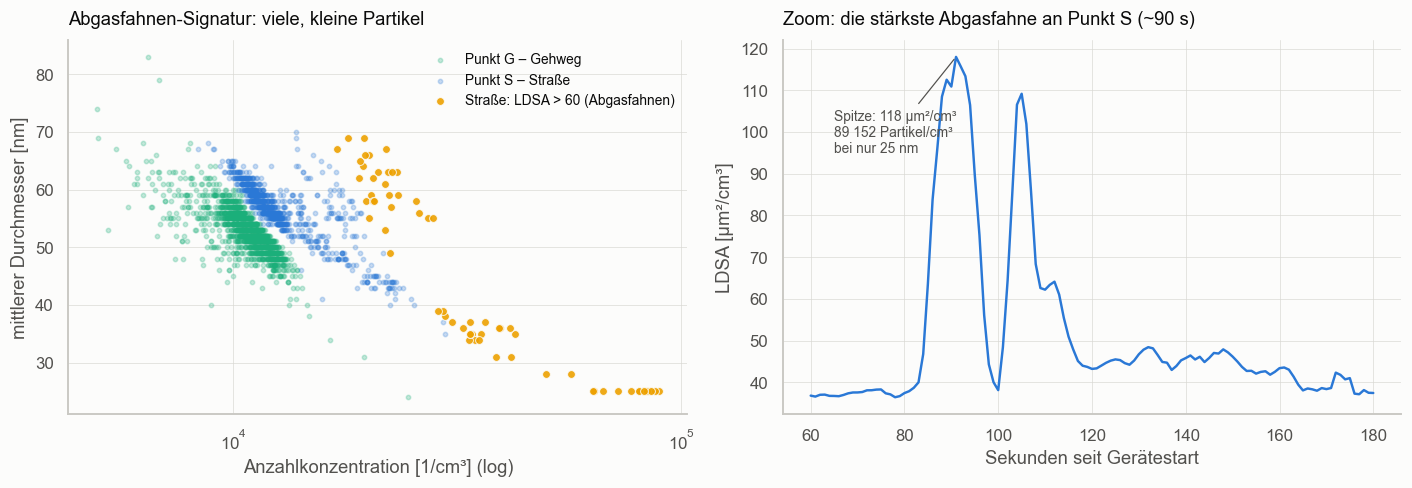

In [9]:
spikes = part_S["LDSA"] > 60
print(f"Punkt S: {spikes.sum()} Sekunden ({spikes.mean()*100:.1f} % der Messzeit) mit LDSA > 60 µm²/cm³ "
      f"– verteilt auf mehrere Abgasfahnen.\nPunkt G: {(part_G['LDSA'] > 60).sum()} Sekunden über 60 µm²/cm³.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.scatter(part_G["number"], part_G["diam"], s=8, alpha=.25, color=COL_G, label="Punkt G – Gehweg")
ax.scatter(part_S.loc[~spikes, "number"], part_S.loc[~spikes, "diam"], s=8, alpha=.25,
           color=COL_S, label="Punkt S – Straße")
ax.scatter(part_S.loc[spikes, "number"], part_S.loc[spikes, "diam"], s=26, alpha=.9,
           color=COL_EV, edgecolor=SURFACE, linewidth=.6, label="Straße: LDSA > 60 (Abgasfahnen)")
ax.set_xscale("log")
ax.set_xlabel("Anzahlkonzentration [1/cm³] (log)"); ax.set_ylabel("mittlerer Durchmesser [nm]")
ax.set_title("Abgasfahnen-Signatur: viele, kleine Partikel")
ax.legend(fontsize=9)

ax = axes[1]
seg = part_S[(part_S["time"] >= 60) & (part_S["time"] <= 180)]
ax.plot(seg["time"], seg["LDSA"], lw=1.6, color=COL_S)
pk = seg.loc[seg["LDSA"].idxmax()]
ax.annotate(f"Spitze: {pk['LDSA']:.0f} µm²/cm³\n{pk['number']:,.0f} Partikel/cm³\nbei nur {pk['diam']:.0f} nm".replace(",", " "),
            xy=(pk["time"], pk["LDSA"]), xytext=(seg["time"].iloc[5], 95),
            fontsize=9, color=INK2, arrowprops=dict(arrowstyle="-", color=INK2, lw=.8))
ax.set_xlabel("Sekunden seit Gerätestart"); ax.set_ylabel("LDSA [µm²/cm³]")
ax.set_title("Zoom: die stärkste Abgasfahne an Punkt S (~90 s)")
plt.tight_layout()

Median    Mittel      Std       P95       Max
Größe          Punkt                                                      
LDSA [µm²/cm³] S – Straße     37.58     42.05    11.42     63.71    118.00
               G – Gehweg     33.00     32.48     2.81     35.51     37.30
number [1/cm³] S – Straße  12058.50  14553.41  8940.49  22826.15  89152.00
               G – Gehweg  10877.00  10745.58  1435.64  12625.45  24563.00
diam [nm]      S – Straße     57.00     55.78     6.70     63.00     70.00
               G – Gehweg     52.00     52.69     4.09     59.00     83.00
mass [µg/m³]   S – Straße      8.89      9.34     2.42     13.71     26.74
               G – Gehweg      6.27      6.26     0.93      7.67     15.02

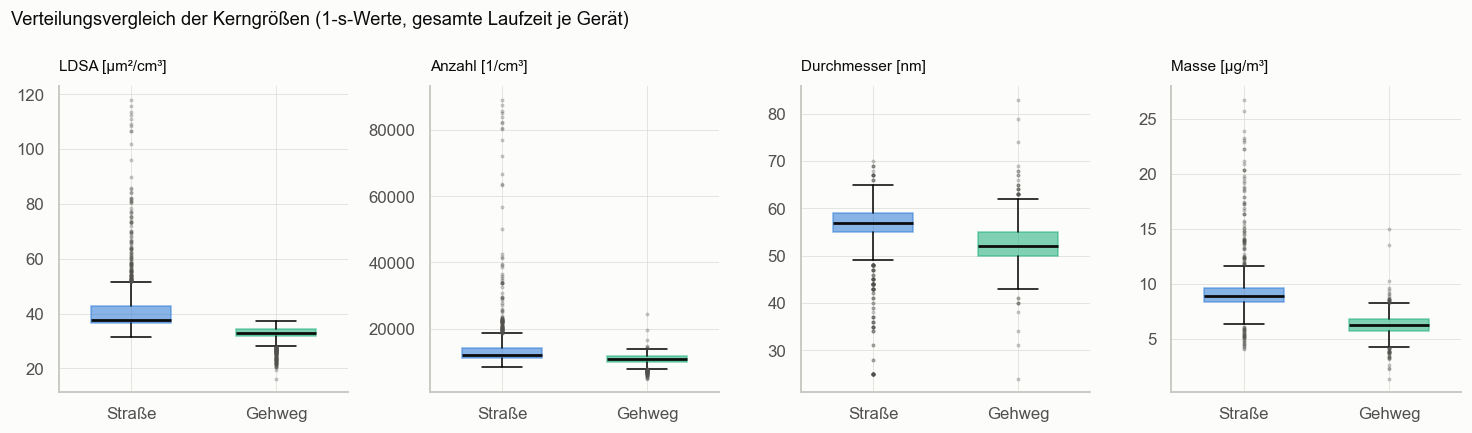

In [10]:
rows = []
for col, unit in [("LDSA", "µm²/cm³"), ("number", "1/cm³"), ("diam", "nm"), ("mass", "µg/m³")]:
    for name, df in [("S – Straße", part_S), ("G – Gehweg", part_G)]:
        x = df[col]
        rows.append({"Größe": f"{col} [{unit}]", "Punkt": name, "Median": x.median(),
                     "Mittel": x.mean(), "Std": x.std(), "P95": x.quantile(.95), "Max": x.max()})
cmp_tbl = pd.DataFrame(rows).set_index(["Größe", "Punkt"]).round(2)
display(cmp_tbl)

fig, axes = plt.subplots(1, 4, figsize=(13.5, 4))
for ax, (col, ylab) in zip(axes, [("LDSA", "LDSA [µm²/cm³]"), ("number", "Anzahl [1/cm³]"),
                                  ("diam", "Durchmesser [nm]"), ("mass", "Masse [µg/m³]")]):
    bp = ax.boxplot([part_S[col], part_G[col]], tick_labels=["Straße", "Gehweg"],
                    widths=.55, patch_artist=True,
                    flierprops=dict(marker=".", markersize=3, alpha=.35, markeredgecolor=INK2),
                    medianprops=dict(color=INK, lw=1.8))
    for patch, c in zip(bp["boxes"], [COL_S, COL_G]):
        patch.set_facecolor(c); patch.set_alpha(.55); patch.set_edgecolor(c)
    ax.set_title(ylab, fontsize=10)
fig.suptitle("Verteilungsvergleich der Kerngrößen (1-s-Werte, gesamte Laufzeit je Gerät)",
             x=.01, ha="left", fontsize=12)
plt.tight_layout()

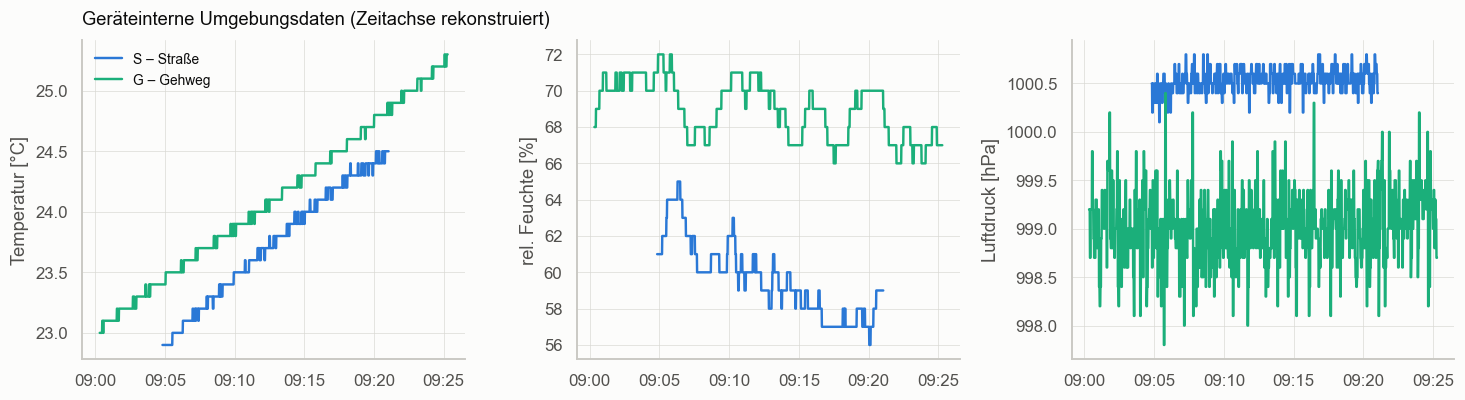

In [11]:
# Kontext: Bordsensorik der beiden Partector (T, RH, P)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, col, ylab in zip(axes, ["T", "RH", "P"],
                         ["Temperatur [°C]", "rel. Feuchte [%]", "Luftdruck [hPa]"]):
    for df, c, label in [(part_S, COL_S, "S – Straße"), (part_G, COL_G, "G – Gehweg")]:
        d = df[df["time"] > 60]  # erste Minute ausblenden (Sensor-Äquilibrierung nach dem Einschalten)
        ax.plot(d["t_real"], d[col], color=c, lw=1.6, label=label)
    ax.set_ylabel(ylab)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[0].legend(fontsize=9)
axes[0].set_title("Geräteinterne Umgebungsdaten (Zeitachse rekonstruiert)")
plt.tight_layout()

Die Bordsensorik ist Plausibilitäts-Gold: Beide Geräte sehen einen **sommerlichen Vormittag** mit
23–25 °C und langsam steigender Temperatur. Der Gehweg-Sensor meldet durchgehend ~9 Prozentpunkte
mehr relative Feuchte (69 % vs. 60 %) – konsistent mit dem Standort im Grünen – und ~1,5 hPa
weniger Druck; Letzteres ist eher Sensor-Offset als Physik (1,5 hPa entsprächen ~12 m
Höhenunterschied auf 44 m Distanz, etwas Geländeanstieg ist dort tatsächlich vorhanden).

## 6. Alles auf einer Zeitachse (rekonstruiert)

Zum Abschluss legen wir beide Messgrößen auf die in Abschnitt 2 rekonstruierte reale Zeitachse –
wohlwissend, dass die Uhr des Straßen-Partectors nur auf ±5 min genau verortet ist. Zwei getrennte
Panels mit gemeinsamer x-Achse (bewusst **keine** Doppel-y-Achse):

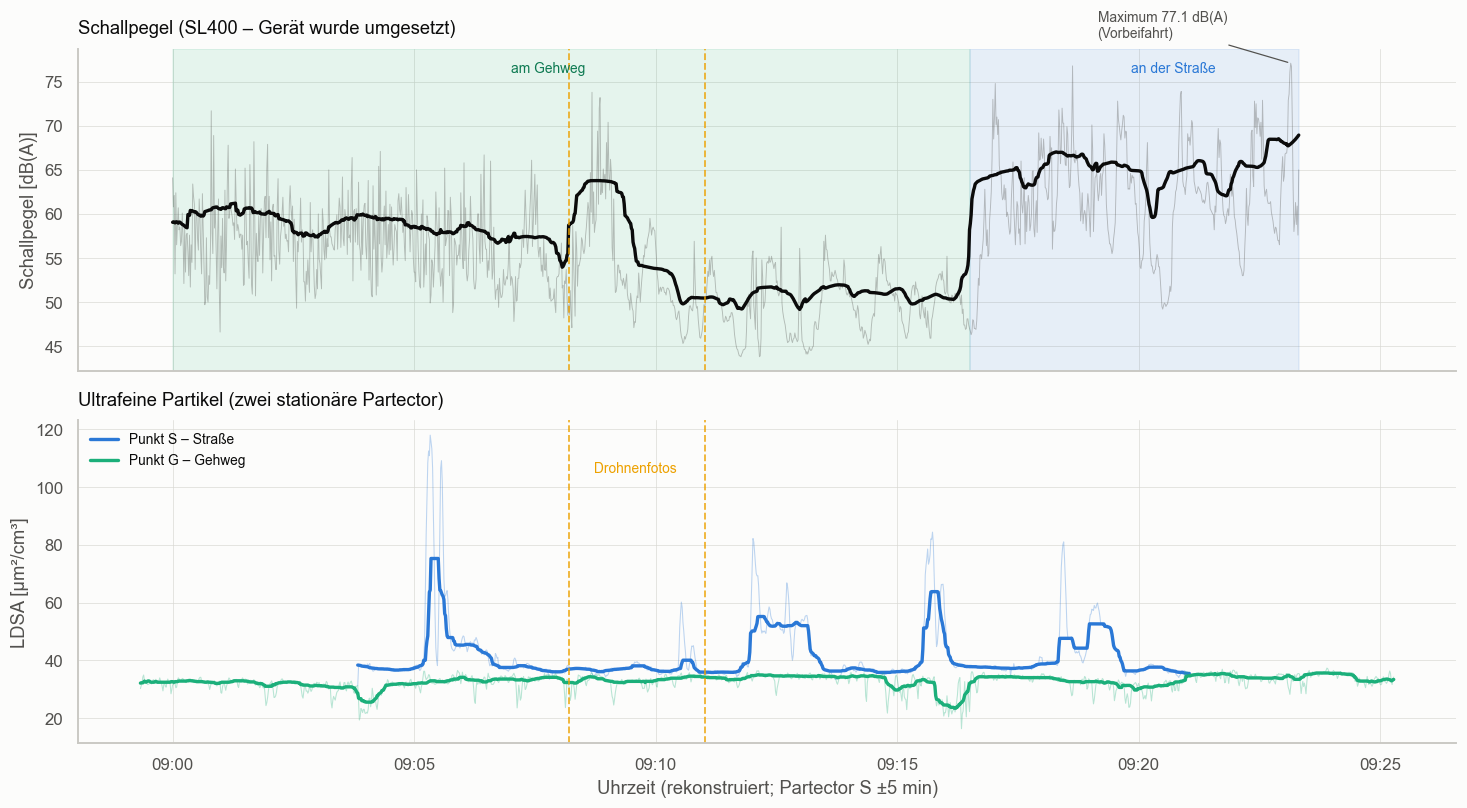

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13.5, 7.5), sharex=True)

ax1.axvspan(db["t_real"].iloc[0], t_switch, color=COL_G, alpha=.10)
ax1.axvspan(t_switch, db["t_real"].iloc[-1], color=COL_S, alpha=.10)
ax1.plot(db["t_real"], v, lw=.6, alpha=.35, color=INK2)
ax1.plot(db["t_real"], db["leq60"], lw=2.2, color=INK, label="60-s-$L_{eq}$")
ax1.set_ylabel("Schallpegel [dB(A)]")
ax1.set_title("Schallpegel (SL400 – Gerät wurde umgesetzt)")
ax1.text(db["t_real"].iloc[420], 76, "am Gehweg", color="#0e7a52", fontsize=9)
ax1.text(db["t_real"].iloc[i_switch + 200], 76, "an der Straße", color=COL_S, fontsize=9)
ax1.annotate(f"Maximum {v[i_max]:.1f} dB(A)\n(Vorbeifahrt)",
            xy=(db["t_real"].iloc[i_max], v[i_max]),
            xytext=(db["t_real"].iloc[i_max] - pd.Timedelta(minutes=4), 80),
            fontsize=9, color=INK2, arrowprops=dict(arrowstyle="-", color=INK2, lw=.8))

for df, c, label in [(part_S, COL_S, "Punkt S – Straße"), (part_G, COL_G, "Punkt G – Gehweg")]:
    ax2.plot(df["t_real"], df["LDSA"], lw=.7, alpha=.3, color=c)
    ax2.plot(df["t_real"], df["LDSA"].rolling(31, center=True, min_periods=10).median(),
             lw=2.2, color=c, label=label)
ax2.set_ylabel("LDSA [µm²/cm³]")
ax2.set_title("Ultrafeine Partikel (zwei stationäre Partector)")
ax2.legend(fontsize=9, loc="upper left")

for ax in (ax1, ax2):
    for _, _, _, t in PHOTOS:
        ax.axvline(pd.Timestamp(f"2026-06-17 {t}"), color=COL_EV, lw=1.2, ls="--", alpha=.8)
ax2.text(pd.Timestamp("2026-06-17 09:09:35"), 105, "Drohnenfotos", color=COL_EV,
         ha="center", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.set_xlabel("Uhrzeit (rekonstruiert; Partector S ±5 min)")
plt.tight_layout()